In [1]:
import torch
import torch.nn as nn
from torchvision import transforms

import matplotlib.pyplot as plt  #libreria per graficare i risultati
import random      #per ottenere valori randomici
from pathlib import Path   #per gestire percorsi file
from PIL import Image      #per gestire le immagini

In [2]:
#Scelta del dispositivo: GPU se disponibile, altrimenti CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classi=['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [3]:
IMG_SIZE = (150, 150)  #dim. immagine
BATCH_SIZE = 64        #dim. batch

#trasformazione per le immagini destinati al test
transformation = transforms.Compose([ 
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

In [4]:
#rete convoluzionale

#struttura precedente (in Pytorch è raccomandato exsportare i pesi dei neuroni e non la struttura)
class CNN(nn.Module):            
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)

        self.pool = nn.MaxPool2d(kernel_size=2)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.3)         
        
        self.fc1 = nn.Linear(128*17*17, 64)
        self.fc2 = nn.Linear(64, num_classes) 

    
    #struttura feedfoward
    def forward(self, x):
        
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))             

        
        x = self.flatten(x) 
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

#viene creato la struttura del modello
model = CNN(num_classes=len(classi)).to(device)

#carica i pesi salvati nel file .pth
model.load_state_dict(torch.load("Modello/model_PyTorch.pth", map_location=device))

<All keys matched successfully>

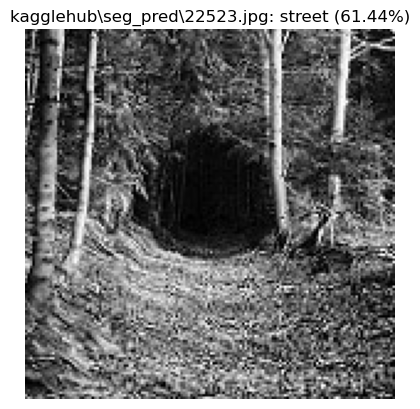

'exit' per uscire o invio per continuare:  


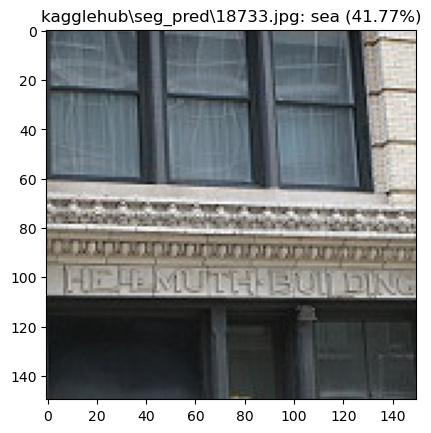

'exit' per uscire o invio per continuare:  


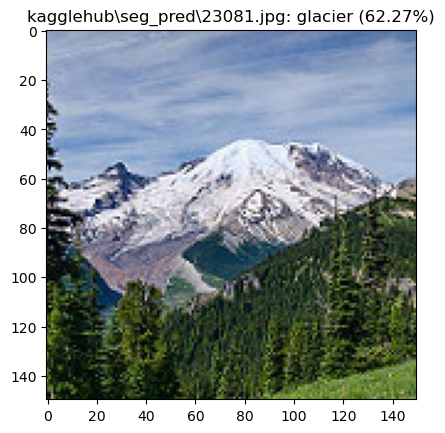

'exit' per uscire o invio per continuare:  


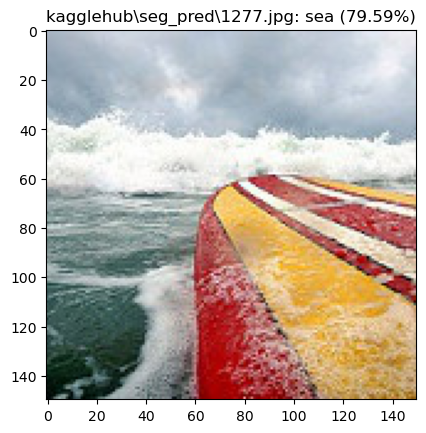

'exit' per uscire o invio per continuare:  


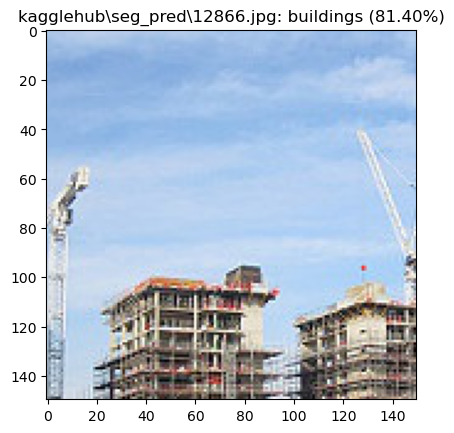

'exit' per uscire o invio per continuare:  exit


In [5]:
#cartella che contiene le immagini
dir_prediction = Path("kagglehub/seg_pred")

#prende tutte le immagini .jpg presenti direttamente nella cartella
images_path = list(dir_prediction.glob("*.jpg"))


check = ""

model.eval() #modello in modalità valutazione

while check != "exit":
    random_image = random.choice(images_path) #sceglie casualmente una immagine dalla lista

    image = Image.open(random_image).convert("RGB") #apre l'immagine

    #trasformazione dell'immagine prima di passare nella rete
    image_tensor = transformation(image)
    image_tensor = image_tensor.unsqueeze(0) #assegna la dimensione della batch=1
    
    image_tensor = image_tensor.to(device)  #caricamento immagine nella GPU
    
    with torch.no_grad():
        
        output = model(image_tensor) #determina l'output del modello  es. [1.2, -0.4, 0.8, 2.5, 0.1, -1.0]
        probability = torch.softmax(output, dim=1) #restituisce l'output in probabilità es. [0.16, 0.03, 0.11, 0.61, 0.07, 0.02]
        
        confidence, predicted = torch.max(probability, dim=1) #restituisce il valore predetto più alto e la posizione del valore

        confidence = confidence.item() * 100 #viene calcolato il valore in percentuale

        #per ottenere il nome della classe predetta
        index = predicted.item()
        classe_pred = classi[index]

    #stampa dell'immagine
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{random_image}: {classe_pred} ({confidence:.2f}%)")
    plt.show()

    check=str(input("'exit' per uscire o invio per continuare: "))